Data Analysis

In [17]:
import os
print(os.listdir())

['.anaconda', '.astropy', '.conda', '.condarc', '.continuum', '.copilot', '.eclipse', '.ibm_cplex_studio', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.metadata', '.virtual_documents', '.vscode', 'anaconda3', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'Documents', 'Downloads', 'Exam_Score_Prediction.csv', 'Favorites', 'Hello.c', 'InstallAnywhere', 'Links', 'Local Settings', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{36031649-fab6-11ed-822e-749779e84e1c}.TM.blf', 'NTUSER.DAT{36031649-fab6-11ed-822e-749779e84e1c}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{36031649-fab6-11ed-822e-749779e84e1c}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'opl', 'PrintHood', 'Project.ipynb', 'Recent', 'Saved Games', 'Searches', 'SendTo', 'Start Menu', 'Templates', 'Untitled.ipynb']


In [5]:
df = pd.read_csv("Exam_Score_Prediction.csv")
df.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  object 
 3   course            20000 non-null  object 
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  object 
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  object 
 9   study_method      20000 non-null  object 
 10  facility_rating   20000 non-null  object 
 11  exam_difficulty   20000 non-null  object 
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 2.0+ MB


In [7]:
df.describe()


,student_id,age,study_hours,class_attendance,sleep_hours,exam_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000
mean,10000.504600,20.473300,4.007604,70.017365,7.00856,62.513225
std,5773.654959,2.284458,2.308313,17.282262,1.73209,18.908491
min,1.000000,17.000000,0.080000,40.600000,4.10000,19.599000
25%,5000.750000,18.000000,2.000000,55.100000,5.50000,48.800000
50%,10000.500000,20.000000,4.040000,69.900000,7.00000,62.600000
75%,15000.250000,22.000000,6.000000,85.000000,8.50000,76.300000
max,20001.000000,24.000000,7.910000,99.400000,9.90000,100.000000


In [8]:
df.isnull().sum()

student_id          0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
print("Shape:", df.shape)
df.sample(10)

Shape: (20000, 13)


,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
15467,15468,18,male,b.com,4.58,52.9,no,7.1,good,coaching,low,moderate,60.2
3614,3615,23,male,b.com,5.23,89.1,yes,5.8,good,coaching,low,hard,84.1
13462,13463,21,female,b.sc,0.27,54.4,yes,8.5,average,group study,medium,easy,47.2
11550,11551,19,male,ba,2.77,76.8,yes,8.3,poor,coaching,high,moderate,48.8
11014,11015,20,female,b.tech,4.02,92.3,yes,9.7,poor,mixed,medium,moderate,88.8
7551,7552,20,female,b.tech,1.83,58.6,yes,9.3,average,group study,medium,moderate,52.3
10686,10687,22,other,bca,1.05,67.7,yes,7.8,good,online videos,low,hard,40.9
4293,4294,17,female,bca,0.21,54.3,yes,5.7,poor,coaching,low,moderate,24.4
12929,12930,21,male,bba,4.87,85.7,no,8.5,average,mixed,medium,easy,54.5
16083,16084,20,other,diploma,2.11,55.2,yes,6.4,poor,coaching,high,moderate,58.2


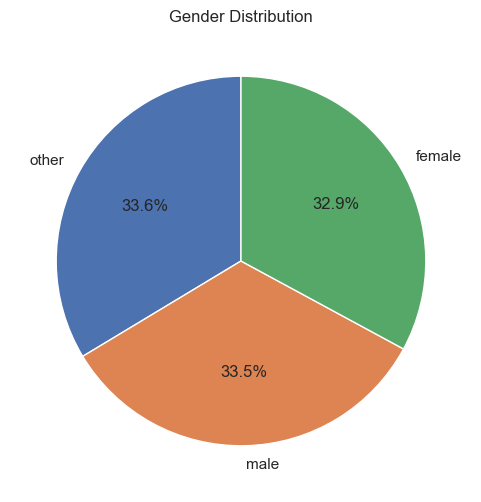

In [12]:
gender_counts = df["gender"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Gender Distribution")
plt.show()


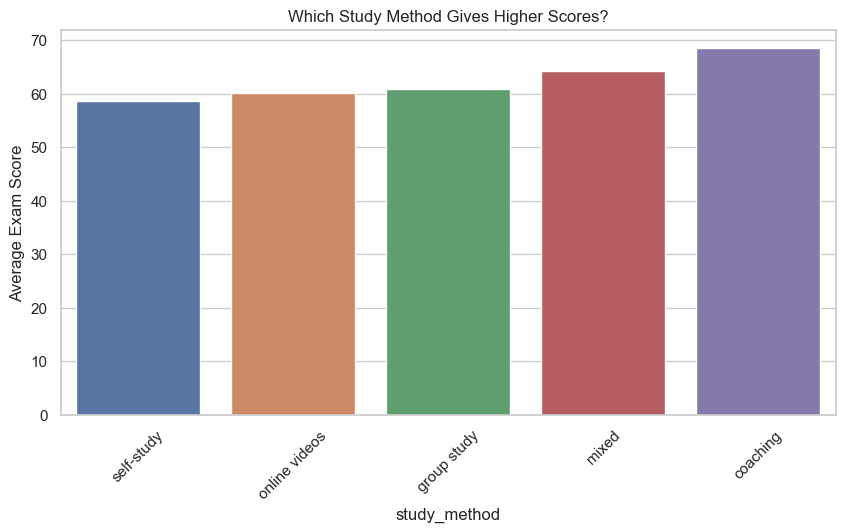

In [13]:
plt.figure(figsize=(10,5))
avg_scores = df.groupby("study_method")["exam_score"].mean().sort_values()

sns.barplot(x=avg_scores.index, y=avg_scores.values)
plt.xticks(rotation=45)
plt.ylabel("Average Exam Score")
plt.title("Which Study Method Gives Higher Scores?")
plt.show()

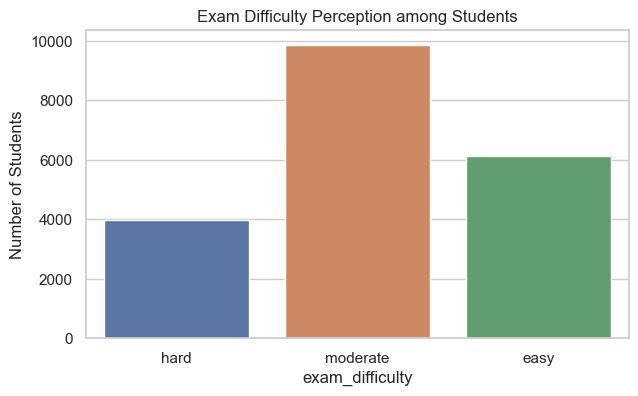

In [14]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x="exam_difficulty")
plt.title("Exam Difficulty Perception among Students")
plt.ylabel("Number of Students")
plt.show()

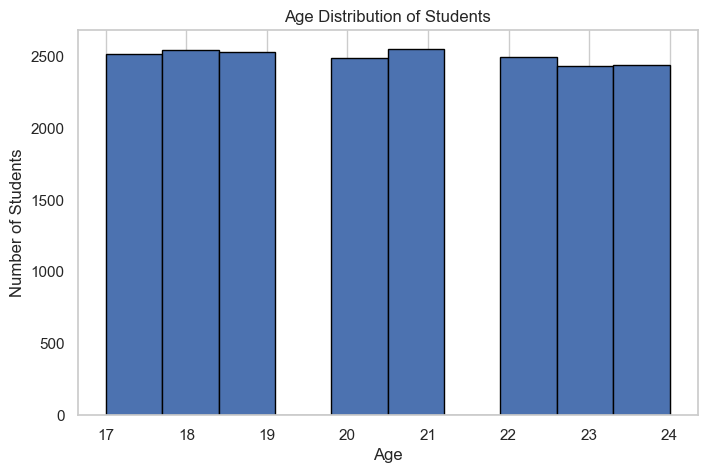

In [15]:
plt.figure(figsize=(8,5))
plt.hist(df["age"], bins=10, edgecolor="black")
plt.title("Age Distribution of Students")
plt.xlabel("Age")
plt.ylabel("Number of Students")
plt.grid(axis='y')
plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_6996\3190484179.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  attendance_score_trend = df.groupby(attendance_bins)["exam_score"].mean().reset_index()


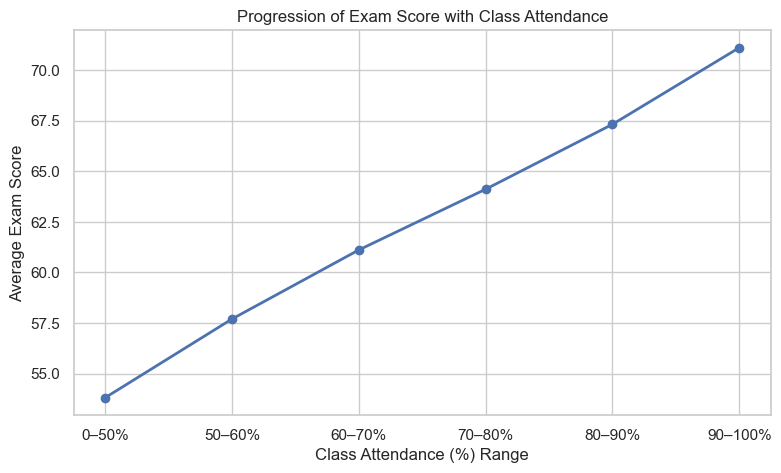

In [25]:
attendance_bins = pd.cut(
    df["class_attendance"],
    bins=[0, 50, 60, 70, 80, 90, 100],
    labels=["0–50%", "50–60%", "60–70%", "70–80%", "80–90%", "90–100%"]
)

attendance_score_trend = df.groupby(attendance_bins)["exam_score"].mean().reset_index()

plt.figure(figsize=(9,5))
plt.plot(attendance_score_trend["class_attendance"], attendance_score_trend["exam_score"],
         marker="o", linewidth=2)

plt.title("Progression of Exam Score with Class Attendance")
plt.xlabel("Class Attendance (%) Range")
plt.ylabel("Average Exam Score")
plt.grid(True)

plt.show()


Prediction Model Build

In [26]:
!pip install xgboost

In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [29]:
df_clean = df.copy()

# Categorical columns
cat_cols = [
    "gender", "course", "internet_access",
    "sleep_quality", "study_method",
    "facility_rating", "exam_difficulty"
]

# Numeric columns
num_cols = [
    "student_id", "age", "study_hours",
    "class_attendance", "sleep_hours"
]

from sklearn.preprocessing import LabelEncoder

le_dict = {}

# Encode categorical columns
for col in cat_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    le_dict[col] = le

# Final Training Data
X = df_clean.drop("exam_score", axis=1)
y = df_clean["exam_score"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Random Forest
rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=12,
    random_state=42
)
rf.fit(X_train, y_train)

# XGBoost
xgb = XGBRegressor(
    n_estimators=350,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=350,
             n_jobs=None, num_parallel_tree=None, ...)

In [33]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Predictions
rf_pred = rf.predict(X_test)
xgb_pred = xgb.predict(X_test)

# R² Score (Higher is better, max 1.0)
rf_r2 = r2_score(y_test, rf_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

# MAE and RMSE
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

print(f"Random Forest → R²: {rf_r2:.4f}, MAE: {rf_mae:.2f}, RMSE: {rf_rmse:.2f}")
print(f"XGBoost       → R²: {xgb_r2:.4f}, MAE: {xgb_mae:.2f}, RMSE: {xgb_rmse:.2f}")

Random Forest → R²: 0.6980, MAE: 8.40, RMSE: 10.39
XGBoost       → R²: 0.7069, MAE: 8.23, RMSE: 10.24
